In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# Rows and Columns
print("Shape:", df.shape)

print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (545, 13)
Missing Values:

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate Rows: 0


In [5]:
df = pd.get_dummies(
    df,
    columns=[
        'mainroad',
        'guestroom',
        'basement',
        'hotwaterheating',
        'airconditioning',
        'prefarea',
        'furnishingstatus'
    ],
    drop_first=True
)

In [6]:
print(df.shape)
print(df.columns)

(545, 14)
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


In [7]:
X = df.drop('price', axis=1)  # Features
y = df['price']               # Target

In [8]:
print(X.head(4))
print(y.head(4))

   area  bedrooms  bathrooms  stories  parking  mainroad_yes  guestroom_yes  \
0  7420         4          2        3        2          True          False   
1  8960         4          4        4        3          True          False   
2  9960         3          2        2        2          True          False   
3  7500         4          2        2        3          True          False   

   basement_yes  hotwaterheating_yes  airconditioning_yes  prefarea_yes  \
0         False                False                 True          True   
1         False                False                 True         False   
2          True                False                False          True   
3          True                False                 True          True   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1                            False                         False  
2                          

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (436, 13)
Testing data shape: (109, 13)


In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [14]:
lr_pred = lr.predict(X_test)

print(lr_pred[:5])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955]


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
mae_lr = mean_absolute_error(y_test, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
r2_lr = r2_score(y_test, lr_pred)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

MAE: 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
rf_pred = rf.predict(X_test)

print(rf_pred[:5])

[5377680.   7287070.   3747528.75 4502120.   3748885.  ]


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [20]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R² Score": [r2_lr, r2_rf]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


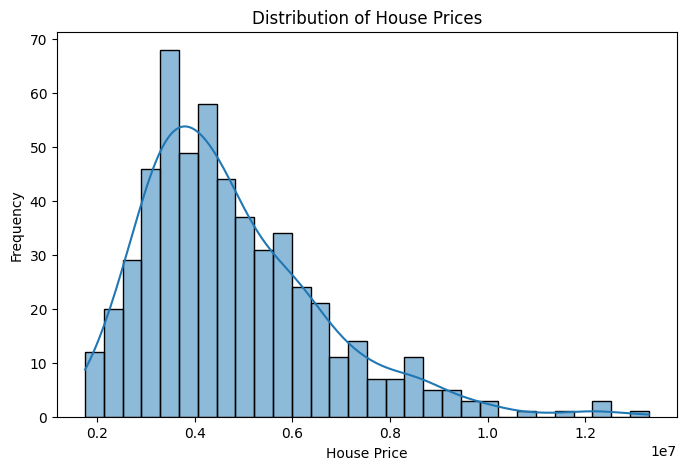

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.savefig("price_distribution.png")
plt.show()

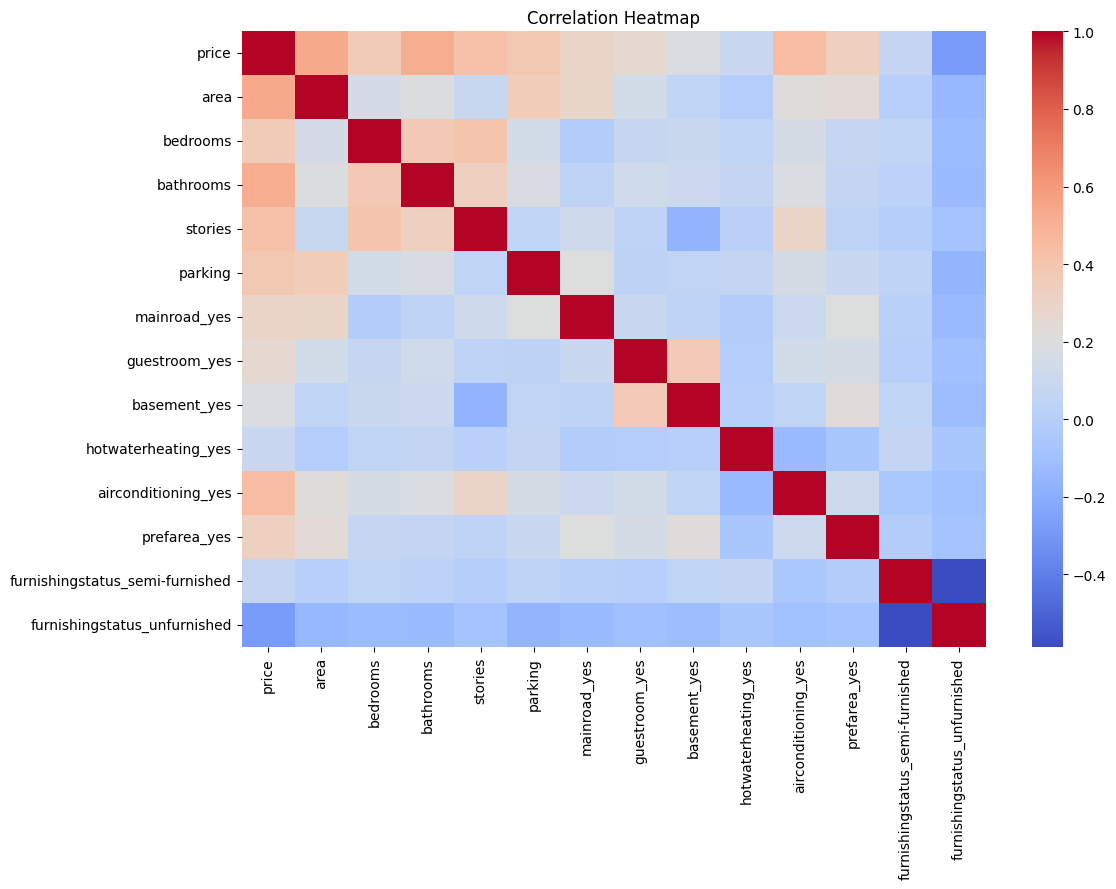

In [22]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")
plt.show()

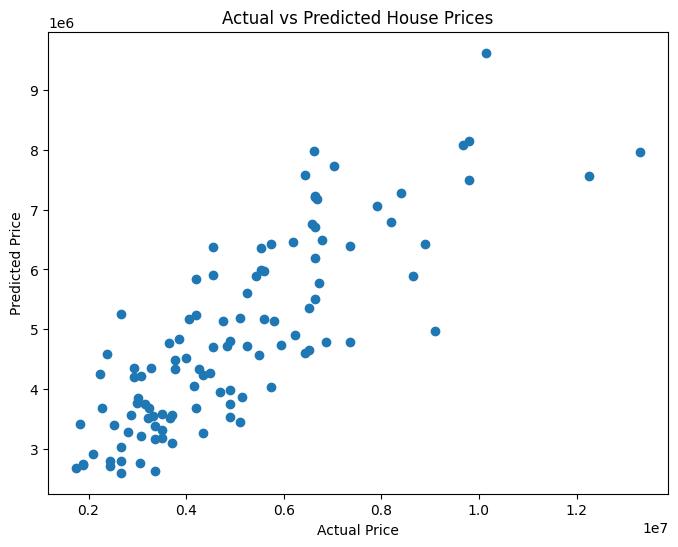

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("actual_vs_predicted.png")
plt.show()

In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                         Feature  Importance
0                           area    0.468430
2                      bathrooms    0.151483
9            airconditioning_yes    0.062672
4                        parking    0.057455
3                        stories    0.057133
1                       bedrooms    0.048413
12  furnishingstatus_unfurnished    0.035011
7                   basement_yes    0.030823
10                  prefarea_yes    0.030689
8            hotwaterheating_yes    0.017226


# Insights and Summary

From the analysis, I found that area has the biggest impact on house prices, followed by bathrooms, air conditioning, parking, and the number of stories. I trained and compared two models, Linear Regression and Random Forest Regressor. Linear Regression gave better results with an R² score of 0.653, which means it was able to explain around 65% of the changes in house prices. One thing that surprised me was how much facilities like air conditioning and parking affected the price of a house. Based on these results, I think real estate businesses should pay special attention to property size and important amenities while deciding house prices.


# Conclusion

In this project, I built a house price prediction model using machine learning techniques and analyzed the factors that affect house prices. After comparing Linear Regression and Random Forest Regressor, Linear Regression performed better on this dataset. The analysis showed that area, bathrooms, and amenities such as air conditioning and parking play an important role in determining house prices. This project helped me understand the complete machine learning workflow, including data cleaning, visualization, model training, evaluation, and interpretation of results.

